# Figure 1(Difficulty)

1. Load Difficulty Result for python 

In [1]:
d_viz_target = input("INPUT 'visualization_target for difficulty RUN_ID'(e.g., run_id_111110000): ")

print(f'Figure will be drawn based on the {d_viz_target} dataset')

Figure will be drawn based on the run_id_111110000 dataset


In [2]:
import pandas as pd
import numpy as np
from datetime import datetime
import os
from glob import glob

from setting_for_sdm.path_setting import path_list
from setting_for_sdm.date_setting import Date_Setting

import lib.annotation.tools.Result_Prep as rp

import lib.stats.stats as st
from lib.utils.file_io import *
from lib.utils.statistics import *
from lib.utils.settings import set_matplotlib
from matplotlib import pyplot as plt
import matplotlib as mpl
import lib.visualization.plot_generator as PlotGen
import lib.visualization.figure_setting as figure_setting

mpl.rcParams.update(figure_setting.fig_setting)




In [3]:
viz_dir = f'{path_list["data_root_dir"]}/result/annotate_difficulty/{d_viz_target}'
data_dir = f"{viz_dir}/data/csv"
option_dict = load_json(f"{viz_dir}/option.json")
output_dir = create_dir('./fig/')
date_range = 'Weekly'

In [4]:
path = f"{viz_dir}/{option_dict['operation_option']['llm_model']}"
file_list = os.listdir(path)
ver_list = sorted([y for y in [x for x in file_list if x.isdigit()]])


In [5]:
r_p = rp.Result_Prep()
tot_calc = pd.DataFrame()
for listid in ver_list:
    df = r_p.make_one_file(listid, path)
    if isinstance(df, pd.core.frame.DataFrame):
        # df = r_p.pp_df(df, 5)
        # df = r_p.calc_rate_byweek(df)
        tot_calc = pd.concat([tot_calc, df], axis = 0)

    

In [6]:
# tmp = load_df('/mnt/hdd/mghan/so_data_availability/result/tag/run_id_100/data', ['cdate' , 'id' , 'tag', 'cnt', 'tot_cnt', 'pct'])

tmp = load_df('/mnt/hdd/mghan/so_data_availability/result/bert_based/run_id_200/data', 
              ['id' , 'creationdate' , 'title', 'tags', 'body', 'Topic'])

    

100%|██████████| 68/68 [00:30<00:00,  2.24it/s]


In [7]:
df = tot_calc[['creationdate', 'id', 'result']].drop_duplicates()

In [8]:
ids = (
    (df.groupby('id')['result'].count() == 1)
    .reset_index(name='is_one')
    .query('is_one == True')['id']
)

In [9]:
tag_tmp = tmp[tmp['id'].isin(ids)]

In [10]:
tag_tmp

,id,creationdate,title,tags,body,Document,Topic
1,72856502,2022-07-04T12:08:42.080000,No module named 'ale_py._ale_py' when importin...,<python><jupyter-notebook><openai-gym>,<p>I get an <strong>No module named 'ale_py._a...,I get an No module named 'ale_py._ale_py' erro...,13
8,72856586,2022-07-04T12:14:55.203000,How can the title be updated in an existing pp...,<python><python-pptx>,<p>I have an title name to update which is dyn...,I have an title name to update which is dynami...,14
25,72854429,2022-07-04T09:20:38.797000,Unable to sign a partially signed transaction ...,<python><solana><anchor-solana>,"<p>in order to buy something on MagicEden, I'm...","in order to buy something on MagicEden, I'm us...",44
64,72855783,2022-07-04T11:09:18.433000,How to Select File from S3 by wildcard matching,<python><amazon-web-services><amazon-s3><boto3>,<p>How to identify/select specific file from S...,How to identify/select specific file from S3 b...,6
75,72857082,2022-07-04T12:50:29.790000,Python file cannot run through PHP button,<python><php>,<p>I have below PHP file which is use to run p...,I have below PHP file which is use to run pyth...,16
...,...,...,...,...,...,...,...
674553,66200278,2021-02-14T21:24:30.903000,Why is my code not probing me to the if or eli...,<python><if-statement>,<p>The code below only skips me to the else: p...,The code below only skips me to the else: part...,8
674721,66203306,2021-02-15T05:51:46.003000,100% RAM usage in google colab,<python><google-colaboratory>,<p>I am currently using google colab for one o...,I am currently using google colab for one of m...,36
674737,66202896,2021-02-15T04:55:17.863000,streamlit.text_area configurability,<python><streamlit>,<p>I wanted to know 2 things.</p>\n<ol>\n<li><...,I wanted to know 2 things.\n\nIs it was possib...,14
674749,66203757,2021-02-15T06:47:54.903000,Error converting shape to a TensorShape when l...,<python><tensorflow><flask><model><pythonanywh...,"<p>I trained a CNN model in a local machine, s...","I trained a CNN model in a local machine, save...",4


In [11]:
tag_list = tag_tmp.loc[tag_tmp['creationdate'] < "2022-11-30", 'Topic'].value_counts().index.to_list()

In [12]:
len(tag_list)

50

In [13]:
topic_num = int(len(tag_list)*0.2)

In [14]:
top_list = tag_list[:topic_num]

In [15]:
bot_list = tag_list[-topic_num : ]

In [16]:
len(bot_list)

10

In [17]:
df

,creationdate,id,result
0,2020-11-01,64627576,<Difficulty Level>1
1,2020-11-01,64627576,<Difficulty Level>2
5,2020-11-01,64628301,<Difficulty Level>0
8,2020-11-01,64628301,<Difficulty Level>1
10,2020-11-01,64628568,<Difficulty Level>0
...,...,...,...
138,2025-05-30,79646101,<Difficulty Level>2
140,2025-05-30,79646158,<Difficulty Level>2
142,2025-05-30,79646158,<Difficulty Level>1
145,2025-05-30,79646202,<Difficulty Level>2


In [18]:
result_df = df[df['id'].isin(ids)].copy()

In [19]:
result_df['result'] = result_df['result'].str.replace('<Difficulty Level>', '')

In [20]:
chk = pd.merge(result_df, tmp[['id', 'Topic']], on = ['id'])
chk['rel_week'] = (pd.to_datetime(chk['creationdate']) - datetime(2022, 11, 30)).dt.days //7
tot_cnt = chk.groupby('rel_week')['id'].count().reset_index()
chk['top_yn'] = chk['Topic'].apply(lambda x :x in top_list)
chk['bot_yn'] = chk['Topic'].apply(lambda x :x in bot_list)

chk['top_q'] = chk['top_yn'] * 1
chk['bot_q'] = chk['bot_yn'] * 1

top_cnt = chk.groupby(['rel_week'])['top_q'].sum().reset_index()
bot_cnt = chk.groupby(['rel_week'])['bot_q'].sum().reset_index()



In [21]:
top_cnt

,rel_week,top_q
0,-104,80
1,-103,52
2,-102,57
3,-101,57
4,-100,61
...,...,...
230,126,24
231,127,34
232,128,34
233,129,42


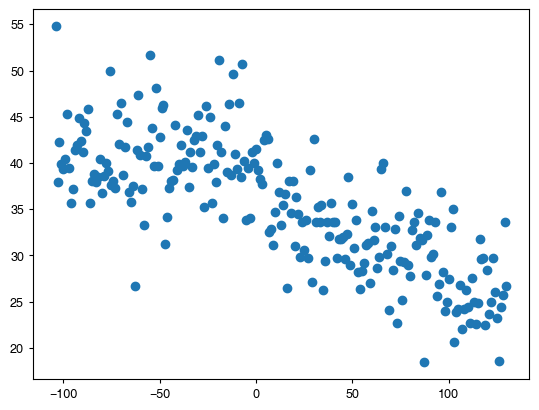

In [22]:
top_df = pd.merge(tot_cnt, top_cnt, on = 'rel_week')
top_df['ratio'] = top_df['top_q']/top_df['id']*100
plt.scatter(top_df['rel_week'], top_df['ratio'])

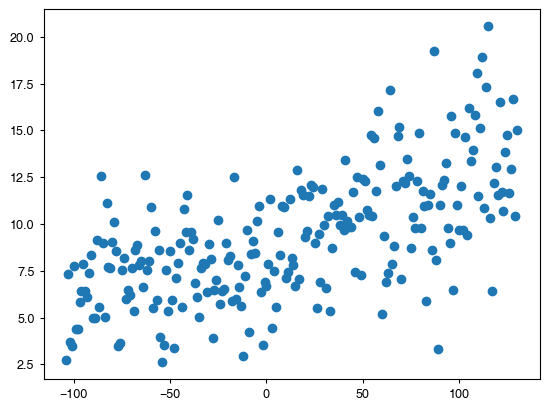

In [23]:
bot_df = pd.merge(tot_cnt, bot_cnt, on = 'rel_week')
bot_df['ratio'] = bot_df['bot_q']/bot_df['id']*100
plt.scatter(bot_df['rel_week'], bot_df['ratio'])

In [24]:
tot_cnt = chk.groupby('rel_week')['id'].count().reset_index()
chk['top_yn'] = chk['Topic'].apply(lambda x :x in top_list)
chk['bot_yn'] = chk['Topic'].apply(lambda x :x in bot_list)

chk['top_q'] = chk['top_yn'] * 1
chk['bot_q'] = chk['bot_yn'] * 1

top_cnt = chk.groupby(['rel_week'])['top_q'].sum().reset_index()
bot_cnt = chk.groupby(['rel_week'])['bot_q'].sum().reset_index()

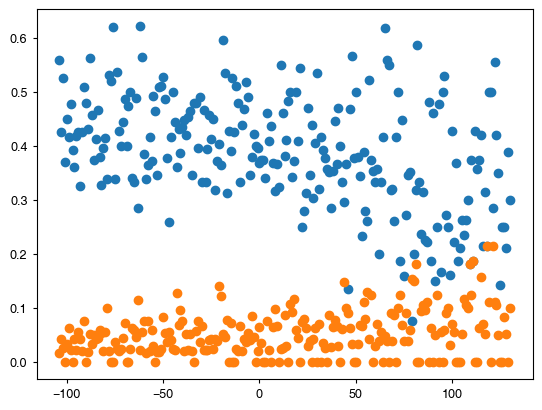

In [25]:
basic_df = result_df[result_df['result'] =='0' ]
basic_df = pd.merge(basic_df, tmp[['id', 'Topic']], on = 'id')
basic_df['rel_week'] = (pd.to_datetime(basic_df['creationdate']) - datetime(2022, 11, 30)).dt.days //7
basic_df['top_yn'] = basic_df['Topic'].apply(lambda x :x in top_list)
basic_df['bot_yn'] = basic_df['Topic'].apply(lambda x :x in bot_list)
basic_tot_q = basic_df.groupby(['rel_week'])['id'].count().reset_index(name='tot_q')

basic_df['top_q'] = basic_df['top_yn'] * 1
basic_df['bot_q'] = basic_df['bot_yn'] * 1
basic_top_q = basic_df.groupby(['rel_week'])['top_q'].sum().reset_index()
basic_bot_q = basic_df.groupby(['rel_week'])['bot_q'].sum().reset_index()

top_df = pd.merge(basic_tot_q, basic_top_q, on = 'rel_week')
bot_df = pd.merge(basic_tot_q, basic_bot_q, on = 'rel_week')
top_df['ratio']= top_df['top_q'] / top_df['tot_q']
bot_df['ratio']= bot_df['bot_q'] / bot_df['tot_q']

plt.scatter(top_df['rel_week'], top_df['ratio'])
plt.scatter(bot_df['rel_week'], bot_df['ratio'])


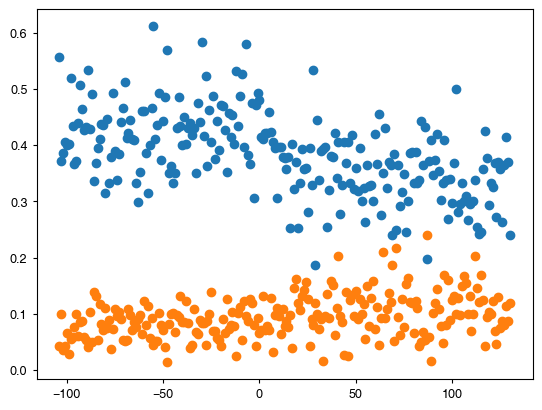

In [26]:
basic_df = result_df[result_df['result'] =='1' ]
basic_df = pd.merge(basic_df, tmp[['id', 'Topic']], on = 'id')
basic_df['rel_week'] = (pd.to_datetime(basic_df['creationdate']) - datetime(2022, 11, 30)).dt.days //7
basic_df['top_yn'] = basic_df['Topic'].apply(lambda x :x in top_list)
basic_df['bot_yn'] = basic_df['Topic'].apply(lambda x :x in bot_list)
basic_tot_q = basic_df.groupby(['rel_week'])['id'].count().reset_index(name='tot_q')

basic_df['top_q'] = basic_df['top_yn'] * 1
basic_df['bot_q'] = basic_df['bot_yn'] * 1
basic_top_q = basic_df.groupby(['rel_week'])['top_q'].sum().reset_index()
basic_bot_q = basic_df.groupby(['rel_week'])['bot_q'].sum().reset_index()

top_df = pd.merge(basic_tot_q, basic_top_q, on = 'rel_week')
bot_df = pd.merge(basic_tot_q, basic_bot_q, on = 'rel_week')
top_df['ratio']= top_df['top_q'] / top_df['tot_q']
bot_df['ratio']= bot_df['bot_q'] / bot_df['tot_q']

plt.scatter(top_df['rel_week'], top_df['ratio'])
plt.scatter(bot_df['rel_week'], bot_df['ratio'])


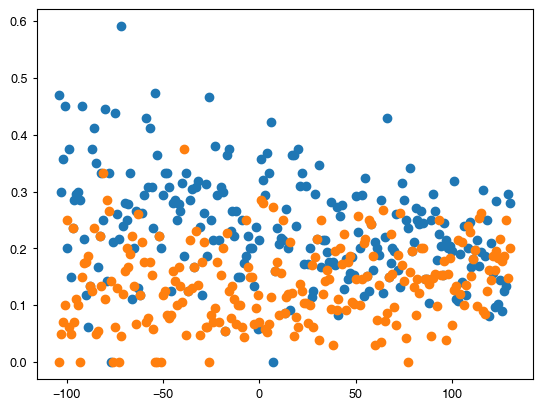

In [27]:
basic_df = result_df[result_df['result'] =='2' ]
basic_df = pd.merge(basic_df, tmp[['id', 'Topic']], on = 'id')
basic_df['rel_week'] = (pd.to_datetime(basic_df['creationdate']) - datetime(2022, 11, 30)).dt.days //7
basic_df['top_yn'] = basic_df['Topic'].apply(lambda x :x in top_list)
basic_df['bot_yn'] = basic_df['Topic'].apply(lambda x :x in bot_list)
basic_tot_q = basic_df.groupby(['rel_week'])['id'].count().reset_index(name='tot_q')

basic_df['top_q'] = basic_df['top_yn'] * 1
basic_df['bot_q'] = basic_df['bot_yn'] * 1
basic_top_q = basic_df.groupby(['rel_week'])['top_q'].sum().reset_index()
basic_bot_q = basic_df.groupby(['rel_week'])['bot_q'].sum().reset_index()

top_df = pd.merge(basic_tot_q, basic_top_q, on = 'rel_week')
bot_df = pd.merge(basic_tot_q, basic_bot_q, on = 'rel_week')
top_df['ratio']= top_df['top_q'] / top_df['tot_q']
bot_df['ratio']= bot_df['bot_q'] / bot_df['tot_q']

plt.scatter(top_df['rel_week'], top_df['ratio'])
plt.scatter(bot_df['rel_week'], bot_df['ratio'])
